molecule: 1
SMILES: O=C([O-])c1ccccc1-c1c2ccc(=O)cc-2oc2cc([O-])ccc12
Match: 1, Atom_idx: (4, 6), Bond_type: single
Match: 2, Atom_idx: (7, 13), Bond_type: single
Drawing molecule 1:


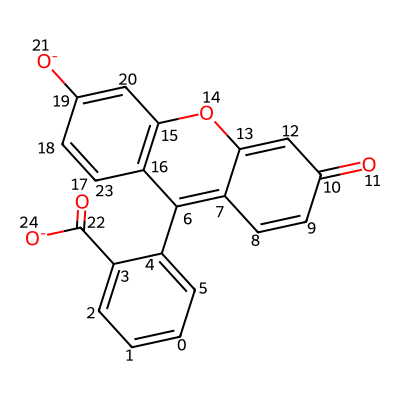

molecule: 2
SMILES: CCN(CC)c1ccc2c(-c3ccccc3C(=O)O)c3ccc(=[N+](CC)CC)cc-3oc2c1
Match: 1, Atom_idx: (11, 24), Bond_type: single
Match: 2, Atom_idx: (12, 22), Bond_type: single
Drawing molecule 2:


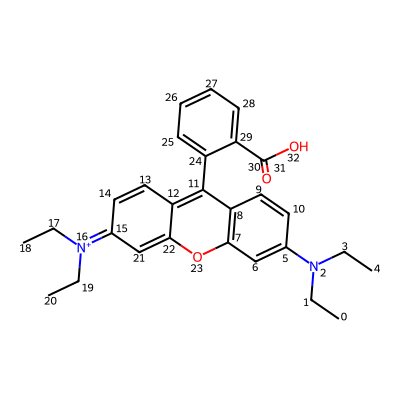

In [ ]:
from IPython.display import display
from rdkit.Chem import BondType, Mol, MolFromSmarts, MolFromSmiles, MolToSmiles
from rdkit.Chem.Draw import MolToImage, rdMolDraw2D
from rdkit.Chem.rdDepictor import Compute2DCoords

smiles = [
    "C1=CC=C(C(=C1)C2=C3C=CC(=O)C=C3OC4=C2C=CC(=C4)[O-])C(=O)[O-]", 
    "CCN(CC)C1=CC2=C(C=C1)C(=C3C=CC(=[N+](CC)CC)C=C3O2)C4=CC=CC=C4C(=O)O"
    ]

smarts = "[c]-[c]"
mols = []

mols = [MolFromSmiles(smile) for smile in smiles]
substructure = MolFromSmarts(smarts)


def get_bond_type_str(mol, atom_idx):
    """Get the bond type between two atoms."""
    bond = mol.GetBondBetweenAtoms(atom_idx[0], atom_idx[1])
    bond_type = bond.GetBondType()
    if bond_type == BondType.SINGLE:
        return "single"
    elif bond_type == BondType.DOUBLE:
        return "double"
    elif bond_type == BondType.TRIPLE:
        return "triple"
    elif bond_type == BondType.AROMATIC:
        return "aromatic"
    else:
        return str(bond_type)


def substruct_match_result(mol, idx, substructure):
    "Substructure query for the aryl-aryl single bond within a molecule."
    
    print(f'molecule: {idx}')
    print(f'SMILES: {MolToSmiles(mol)}')

    matches = mol.GetSubstructMatches(substructure)
    for hit, atom_idx in enumerate(matches, start=1):
        bond_str = get_bond_type_str(mol, atom_idx)
        print(f'Match: {hit}, Atom_idx: {atom_idx}, Bond_type: {bond_str}')


def draw_molecule_with_indices(mol, size=(400, 400)):
    """Draw a molecule with atom indices using RDKit."""
    # Compute 2D coordinates
    Compute2DCoords(mol)
    
    # Create draw options
    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.addAtomIndices = True
    draw_options.annotationFontScale = 0.8  # Adjust font size for indices
    
    # Generate image
    img = MolToImage(mol, size=size, options=draw_options)
    return img

# Process each molecule: show structural formula and substructure query results
for idx, mol in enumerate(mols, start=1):
    substruct_match_result(mol, idx, substructure)
    print(f"Drawing molecule {idx}:")
    img = draw_molecule_with_indices(mol)
    display(img)

# Literature confirming the results are incorret: dx.doi.org/10.1021/jp207459k